In [2]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.models.train_model.train_model import *

In [3]:
def train_model(df_train, model_X_cols, n_mimo, param,save_model=False, save_model_folder=None):
    feature_selector = Feature_selector(df_train, target="generation")
    Xs_train, ys_train, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    Xs_train = Xs_train.reindex(columns=model_X_cols)
    Xs_train = Xs_train.fillna(False).infer_objects()

    # model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=2000, max_depth=7, learning_rate=0.1)
    model = RandomForestRegressor(n_estimators=param["n_est"], max_depth=param["m_depth"], random_state=42)
    model.fit(Xs_train, ys_train)
    logger.info(f"Model has been trained successfully")

    ys_pred = model.predict(Xs_train)

    y_pred = get_y_inverse_mimo(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = get_y_inverse_mimo(df_train, feature_selector, name_code_df, n_mimo, ys_train)

    rmse_error_train = compute_relative_rmse(y_pred, y_train)
    thresh_error_train = compute_threshold_error(y_pred, y_train)
    rmae_error = compute_relative_mae(y_pred, y_train)
    r2_score = compute_r2_score(y_pred, y_train)
    #logger.info(f"Train rmse error: {rmse_error_train:0.3f}%")
    #logger.info(f"Train threshold error: {thresh_error_train:0.3f}%")
    #logger.info(f"Train rmae error: {rmae_error:0.3f}%")
    #logger.info(f"R2 score: {r2_score:0.3f}%")
    return model,(rmse_error_train,thresh_error_train,rmae_error,r2_score)
    if save_model and save_model_folder is not None:
        for filename in os.listdir(save_model_folder):
            os.remove(os.path.join(save_model_folder, filename))

        dump(model, f"{save_model_folder}/model.joblib")
        with open(f"{save_model_folder}/model_cols.pkl", 'wb') as f:
            dump(model_X_cols, f)

In [4]:
def test_model(model, df_test, model_X_cols, n_mimo):
    feature_selector = Feature_selector(df_test, target="generation")
    Xs_test, ys_test, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    Xs_test = Xs_test.reindex(columns=model_X_cols)
    Xs_test = Xs_test.fillna(False).infer_objects()

    ys_pred = model.predict(Xs_test)
    y_pred = get_y_inverse_mimo(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = get_y_inverse_mimo(df_test, feature_selector, name_code_df, n_mimo, ys_test)

    rmse_error_test = compute_relative_rmse(y_pred, y_test)
    thresh_error_test = compute_threshold_error(y_pred, y_test)
    rmae_error = compute_relative_mae(y_pred, y_test)
    r2_score = compute_r2_score(y_pred, y_test)
    return rmse_error_test,thresh_error_test,rmae_error,r2_score
 
    logger.info(f"Test rmse error: {rmse_error_test:0.3f}%")
    logger.info(f"Test threshold error: {thresh_error_test:0.3f}%")
    logger.info(f"Test rmae error: {rmae_error:0.3f}%")
    logger.info(f"R2 score: {r2_score:0.3f}%")

In [5]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

add_is_test_column(df, random_state=42)

save_model = True
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")
n_mimo = 4

df_r_selected = Data_selector(df).select_peaks(goodness=3)

base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                    "forecast", "status"]
features_with_lag = ["temperature", "humidity", "dew", "surface_pressure"]
hours_delay = [1, 5]
lag_features = [f"{feature}_with_{hour}_delay" for feature in features_with_lag for hour in hours_delay]
# lag_features.append("generation_with_24_delay")
time_features = ["hour", "day_of_week", "month", "season", "datetime"]
df_f_selected = select_dataset_features(df_r_selected, base_features, lag_features, time_features, "generation")

model_X_cols = find_after_mimo_cols(df_f_selected, n_mimo)

train_indices = (df_r_selected['is_test'] == False)
train_df = df_f_selected[train_indices]
param = {"n_est":10,"m_depth":10}
model,e = train_model(train_df, model_X_cols, n_mimo,param=param, save_model=save_model, save_model_folder=save_model_folder)
test_indices = (df_r_selected['is_test'] == True)
test_df = df_f_selected[test_indices]
test_model(model, test_df, model_X_cols, n_mimo)

2025-09-29 11:59:31 - train_model - INFO - Some features have been dropped successfully
2025-09-29 11:59:55 - train_model - INFO - Model has been trained successfully


(4.076060151527603, 67.09512992409552, 2.7120639958950625, 0.9789149795023209)

In [6]:
def r_a(a):
    return " - ".join([f"{round(x,3):0.3f}" for x in a])
def show(error):
    for k in error:
        print(f"n_est {k[0]} m_depth {k[1]} => {r_a(error[k])}")

In [7]:
def check(params):
    error = {}
    for n_est in params["n_est"]:
        for m_depth in params["m_depth"]:
            param={"n_est":n_est,"m_depth":m_depth}
            model,e = train_model(train_df, model_X_cols, n_mimo,param=param, save_model=save_model, save_model_folder=save_model_folder)
            rmse_error_train,thresh_error_train,rmae_error,r2_score = test_model(model, test_df, model_X_cols, n_mimo)
            error[(n_est,m_depth)] = (rmse_error_train,thresh_error_train,rmae_error,r2_score)+e
            print(f"n_est {n_est} m_depth {m_depth} => {r_a(error[(n_est,m_depth)])}")
    return error

In [8]:
params={"n_est":[5],"m_depth":[5]}
error = check(params)
show(error)

2025-09-29 12:00:05 - train_model - INFO - Model has been trained successfully


n_est 5 m_depth 5 => 5.775 - 78.852 - 4.020 - 0.958 - 5.746 - 78.121 - 3.895 - 0.961
n_est 5 m_depth 5 => 5.775 - 78.852 - 4.020 - 0.958 - 5.746 - 78.121 - 3.895 - 0.961


In [9]:
params={"n_est":range(20,100,10),"m_depth":range(20,100,5)}
error = check(params)
show(error)

2025-09-29 12:00:54 - train_model - INFO - Model has been trained successfully


n_est 20 m_depth 20 => 2.752 - 53.216 - 1.729 - 0.990 - 1.209 - 19.795 - 0.708 - 0.998


2025-09-29 12:01:46 - train_model - INFO - Model has been trained successfully


n_est 20 m_depth 25 => 2.730 - 52.302 - 1.707 - 0.991 - 0.970 - 13.092 - 0.543 - 0.999


2025-09-29 12:02:39 - train_model - INFO - Model has been trained successfully


...

n_est 90 m_depth 85 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999


2025-09-29 16:52:59 - train_model - INFO - Model has been trained successfully


n_est 90 m_depth 90 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999


2025-09-29 16:57:04 - train_model - INFO - Model has been trained successfully


n_est 90 m_depth 95 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 20 m_depth 20 => 2.752 - 53.216 - 1.729 - 0.990 - 1.209 - 19.795 - 0.708 - 0.998
n_est 20 m_depth 25 => 2.730 - 52.302 - 1.707 - 0.991 - 0.970 - 13.092 - 0.543 - 0.999
n_est 20 m_depth 30 => 2.713 - 52.097 - 1.699 - 0.991 - 0.941 - 11.758 - 0.515 - 0.999
n_est 20 m_depth 35 => 2.718 - 52.114 - 1.696 - 0.991 - 0.940 - 11.657 - 0.513 - 0.999
n_est 20 m_depth 40 => 2.718 - 52.003 - 1.694 - 0.991 - 0.940 - 11.656 - 0.513 - 0.999
n_est 20 m_depth 45 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 50 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 55 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 60 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 65 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 70 => 2.715 - 52.180 - 1.6

In [1]:
gfg = '''n_est 90 m_depth 95 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 20 m_depth 20 => 2.752 - 53.216 - 1.729 - 0.990 - 1.209 - 19.795 - 0.708 - 0.998
n_est 20 m_depth 25 => 2.730 - 52.302 - 1.707 - 0.991 - 0.970 - 13.092 - 0.543 - 0.999
n_est 20 m_depth 30 => 2.713 - 52.097 - 1.699 - 0.991 - 0.941 - 11.758 - 0.515 - 0.999
n_est 20 m_depth 35 => 2.718 - 52.114 - 1.696 - 0.991 - 0.940 - 11.657 - 0.513 - 0.999
n_est 20 m_depth 40 => 2.718 - 52.003 - 1.694 - 0.991 - 0.940 - 11.656 - 0.513 - 0.999
n_est 20 m_depth 45 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 50 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 55 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 60 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 65 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 70 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 75 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 80 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 85 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 90 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 20 m_depth 95 => 2.715 - 52.180 - 1.694 - 0.991 - 0.940 - 11.643 - 0.514 - 0.999
n_est 30 m_depth 20 => 2.725 - 52.784 - 1.717 - 0.991 - 1.185 - 19.269 - 0.695 - 0.998
n_est 30 m_depth 25 => 2.695 - 51.842 - 1.690 - 0.991 - 0.945 - 12.513 - 0.534 - 0.999
n_est 30 m_depth 30 => 2.685 - 51.992 - 1.686 - 0.991 - 0.916 - 11.235 - 0.505 - 0.999
n_est 30 m_depth 35 => 2.682 - 52.036 - 1.680 - 0.991 - 0.915 - 11.070 - 0.503 - 0.999
n_est 30 m_depth 40 => 2.687 - 52.036 - 1.681 - 0.991 - 0.915 - 11.115 - 0.503 - 0.999
n_est 30 m_depth 45 => 2.686 - 52.047 - 1.682 - 0.991 - 0.915 - 11.106 - 0.504 - 0.999
n_est 30 m_depth 50 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 55 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 60 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 65 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 70 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 75 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 80 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 85 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 90 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 30 m_depth 95 => 2.686 - 52.069 - 1.682 - 0.991 - 0.915 - 11.109 - 0.504 - 0.999
n_est 40 m_depth 20 => 2.712 - 52.463 - 1.707 - 0.991 - 1.171 - 18.750 - 0.687 - 0.998
n_est 40 m_depth 25 => 2.688 - 51.682 - 1.681 - 0.991 - 0.937 - 12.227 - 0.527 - 0.999
n_est 40 m_depth 30 => 2.674 - 51.598 - 1.674 - 0.991 - 0.907 - 10.865 - 0.498 - 0.999
n_est 40 m_depth 35 => 2.675 - 51.693 - 1.672 - 0.991 - 0.908 - 10.768 - 0.497 - 0.999
n_est 40 m_depth 40 => 2.672 - 51.454 - 1.670 - 0.991 - 0.908 - 10.759 - 0.497 - 0.999
n_est 40 m_depth 45 => 2.672 - 51.510 - 1.670 - 0.991 - 0.908 - 10.765 - 0.497 - 0.999
n_est 40 m_depth 50 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 55 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 60 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 65 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 70 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 75 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 80 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 85 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 90 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 40 m_depth 95 => 2.672 - 51.493 - 1.670 - 0.991 - 0.908 - 10.781 - 0.497 - 0.999
n_est 50 m_depth 20 => 2.701 - 52.380 - 1.699 - 0.991 - 1.164 - 18.670 - 0.682 - 0.998
n_est 50 m_depth 25 => 2.674 - 51.510 - 1.674 - 0.991 - 0.933 - 12.048 - 0.524 - 0.999
n_est 50 m_depth 30 => 2.664 - 51.504 - 1.669 - 0.991 - 0.902 - 10.798 - 0.496 - 0.999
n_est 50 m_depth 35 => 2.666 - 51.526 - 1.668 - 0.991 - 0.903 - 10.628 - 0.494 - 0.999
n_est 50 m_depth 40 => 2.660 - 51.537 - 1.665 - 0.991 - 0.903 - 10.645 - 0.495 - 0.999
n_est 50 m_depth 45 => 2.660 - 51.543 - 1.666 - 0.991 - 0.903 - 10.648 - 0.495 - 0.999
n_est 50 m_depth 50 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 55 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 60 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 65 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 70 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 75 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 80 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 85 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 90 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 50 m_depth 95 => 2.660 - 51.576 - 1.666 - 0.991 - 0.903 - 10.658 - 0.495 - 0.999
n_est 60 m_depth 20 => 2.699 - 52.230 - 1.696 - 0.991 - 1.157 - 18.550 - 0.679 - 0.998
n_est 60 m_depth 25 => 2.670 - 51.593 - 1.671 - 0.991 - 0.925 - 11.897 - 0.521 - 0.999
n_est 60 m_depth 30 => 2.662 - 51.460 - 1.667 - 0.991 - 0.896 - 10.671 - 0.494 - 0.999
n_est 60 m_depth 35 => 2.667 - 51.598 - 1.668 - 0.991 - 0.895 - 10.567 - 0.492 - 0.999
n_est 60 m_depth 40 => 2.660 - 51.427 - 1.665 - 0.991 - 0.895 - 10.568 - 0.492 - 0.999
n_est 60 m_depth 45 => 2.661 - 51.471 - 1.666 - 0.991 - 0.896 - 10.563 - 0.492 - 0.999
n_est 60 m_depth 50 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 55 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 60 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 65 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 70 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 75 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 80 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 85 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 90 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 60 m_depth 95 => 2.661 - 51.449 - 1.666 - 0.991 - 0.895 - 10.564 - 0.492 - 0.999
n_est 70 m_depth 20 => 2.689 - 52.280 - 1.693 - 0.991 - 1.152 - 18.648 - 0.679 - 0.998
n_est 70 m_depth 25 => 2.657 - 51.571 - 1.667 - 0.991 - 0.921 - 11.987 - 0.521 - 0.999
n_est 70 m_depth 30 => 2.654 - 51.360 - 1.663 - 0.991 - 0.891 - 10.706 - 0.494 - 0.999
n_est 70 m_depth 35 => 2.654 - 51.454 - 1.664 - 0.991 - 0.889 - 10.662 - 0.491 - 0.999
n_est 70 m_depth 40 => 2.650 - 51.238 - 1.662 - 0.991 - 0.889 - 10.645 - 0.492 - 0.999
n_est 70 m_depth 45 => 2.650 - 51.327 - 1.662 - 0.991 - 0.889 - 10.642 - 0.492 - 0.999
n_est 70 m_depth 50 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 55 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 60 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 65 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 70 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 75 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 80 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 85 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 90 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 70 m_depth 95 => 2.650 - 51.360 - 1.662 - 0.991 - 0.889 - 10.654 - 0.492 - 0.999
n_est 80 m_depth 20 => 2.692 - 52.224 - 1.694 - 0.991 - 1.148 - 18.546 - 0.678 - 0.998
n_est 80 m_depth 25 => 2.661 - 51.626 - 1.669 - 0.991 - 0.916 - 11.912 - 0.520 - 0.999
n_est 80 m_depth 30 => 2.659 - 51.582 - 1.665 - 0.991 - 0.886 - 10.603 - 0.493 - 0.999
n_est 80 m_depth 35 => 2.659 - 51.615 - 1.667 - 0.991 - 0.884 - 10.620 - 0.491 - 0.999
n_est 80 m_depth 40 => 2.654 - 51.449 - 1.664 - 0.991 - 0.886 - 10.538 - 0.491 - 0.999
n_est 80 m_depth 45 => 2.653 - 51.460 - 1.664 - 0.991 - 0.886 - 10.538 - 0.491 - 0.999
n_est 80 m_depth 50 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 55 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 60 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 65 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 70 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 75 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 80 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 85 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 90 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 80 m_depth 95 => 2.653 - 51.443 - 1.664 - 0.991 - 0.886 - 10.541 - 0.491 - 0.999
n_est 90 m_depth 20 => 2.685 - 52.346 - 1.692 - 0.991 - 1.143 - 18.512 - 0.677 - 0.998
n_est 90 m_depth 25 => 2.656 - 51.537 - 1.667 - 0.991 - 0.911 - 11.848 - 0.519 - 0.999
n_est 90 m_depth 30 => 2.655 - 51.465 - 1.664 - 0.991 - 0.883 - 10.528 - 0.492 - 0.999
n_est 90 m_depth 35 => 2.654 - 51.526 - 1.665 - 0.991 - 0.880 - 10.485 - 0.490 - 0.999
n_est 90 m_depth 40 => 2.649 - 51.388 - 1.662 - 0.991 - 0.881 - 10.415 - 0.490 - 0.999
n_est 90 m_depth 45 => 2.648 - 51.338 - 1.662 - 0.991 - 0.881 - 10.445 - 0.490 - 0.999
n_est 90 m_depth 50 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 55 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 60 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 65 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 70 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 75 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 80 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 85 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 90 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999
n_est 90 m_depth 95 => 2.648 - 51.382 - 1.662 - 0.991 - 0.881 - 10.440 - 0.490 - 0.999'''

In [4]:
error = {}
for e in gfg.split("\n"):
    p = e.split()
    e1 = float(p[1])
    e3 = float(p[3])
    e5 = float(p[5])
    e7 = float(p[7])
    e9 = float(p[9])
    e11 = float(p[11])
    e13 = float(p[13])
    e15 = float(p[15])
    e17 = float(p[17])
    e19 = float(p[19])
    error[(e1,e3)] = (e5,e7,e9,e11,e13,e15,e17,e19)

2.648


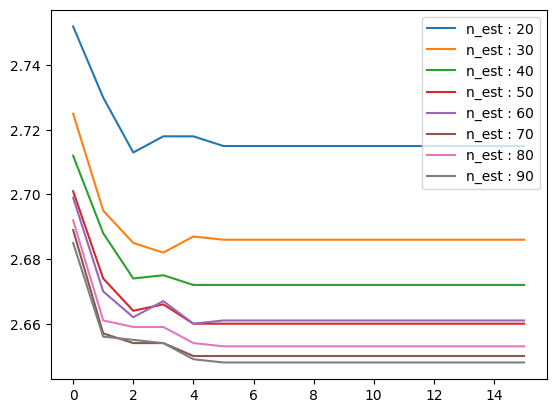

In [6]:
import matplotlib.pyplot as plt
m = 100
for n_est in range(20,100,10):
    a = []
    for m_depth in range(20,100,5):
        a.append(error[(n_est,m_depth)][0])
    m = min(m,min(a))
    plt.plot(a,label=f"n_est : {n_est}")
plt.legend()
print(m)

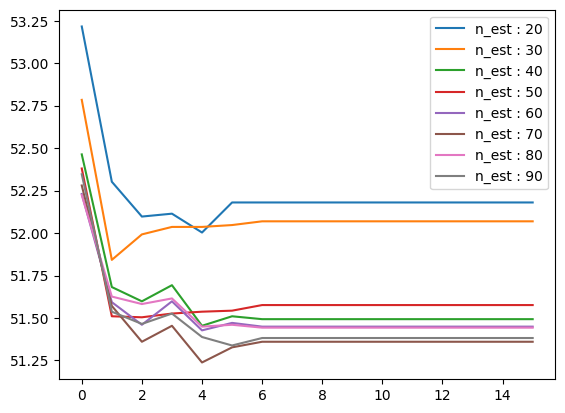

In [7]:
for n_est in range(20,100,10):
    a = []
    for m_depth in range(20,100,5):
        a.append(error[(n_est,m_depth)][1])
    plt.plot(a,label=f"n_est : {n_est}")
plt.legend()

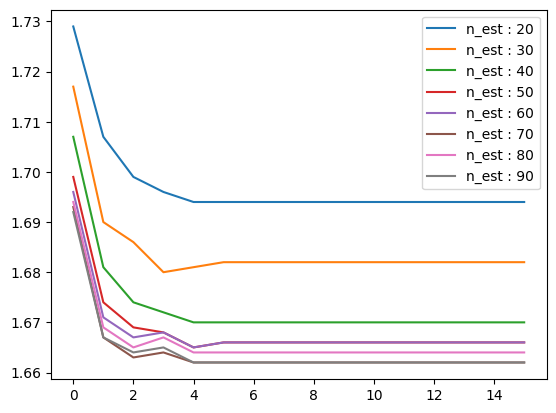

In [8]:
for n_est in range(20,100,10):
    a = []
    for m_depth in range(20,100,5):
        a.append(error[(n_est,m_depth)][2])
    plt.plot(a,label=f"n_est : {n_est}")
plt.legend()

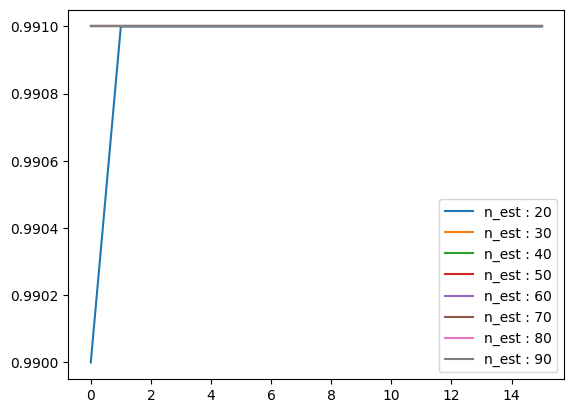

In [9]:
for n_est in range(20,100,10):
    a = []
    for m_depth in range(20,100,5):
        a.append(error[(n_est,m_depth)][3])
    plt.plot(a,label=f"n_est : {n_est}")
plt.legend()

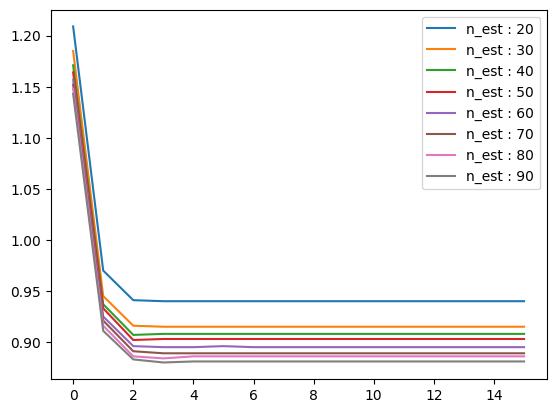

In [10]:
for n_est in range(20,100,10):
    a = []
    for m_depth in range(20,100,5):
        a.append(error[(n_est,m_depth)][4])
    plt.plot(a,label=f"n_est : {n_est}")
plt.legend()